# Taiwanese Company Bankruptcy Prediction
## Decision Tree Classification

**Dataset:** Taiwanese Company Bankruptcy Prediction  
**Source:** [Kaggle](https://www.kaggle.com/code/bhavanjuli/taiwanese-company-bankruptcy-prediction/input) (originally from UCI ML Repository)  
**Instances:** 6,819 | **Attributes:** 96 (95 features + 1 target: `Bankrupt?`)

### Objective
Apply the Decision Tree classification algorithm to predict whether a Taiwanese company will go bankrupt based on 95 financial indicators. This notebook addresses two core challenges in this dataset:
- **Class Imbalance:** Only ~3.2% of companies are bankrupt (minority class)
- **Overfitting:** Decision Trees are prone to memorising training data if left unconstrained

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & feature selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# SMOTE for class imbalance
from imblearn.over_sampling import SMOTE

# Decision Tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load the Dataset

In [2]:
# Load the dataset
df = pd.read_csv("data.csv")

print("First 5 rows:")
df.head()

First 5 rows:


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [3]:
print("Shape of dataset:", df.shape)
print("\nTotal columns:", len(df.columns))
print("\nColumn names:")
print(df.columns.tolist())

Shape of dataset: (6819, 96)

Total columns: 96

Column names:
['Bankrupt?', ' ROA(C) before interest and depreciation before interest', ' ROA(A) before interest and % after tax', ' ROA(B) before interest and depreciation after tax', ' Operating Gross Margin', ' Realized Sales Gross Margin', ' Operating Profit Rate', ' Pre-tax net Interest Rate', ' After-tax net Interest Rate', ' Non-industry income and expenditure/revenue', ' Continuous interest rate (after tax)', ' Operating Expense Rate', ' Research and development expense rate', ' Cash flow rate', ' Interest-bearing debt interest rate', ' Tax rate (A)', ' Net Value Per Share (B)', ' Net Value Per Share (A)', ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons', ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)', ' Operating Profit Per Share (Yuan ¥)', ' Per Share Net profit before tax (Yuan ¥)', ' Realized Sales Gross Profit Growth Rate', ' Operating Profit Growth Rate', ' After-tax Net Profit Growth Rate', ' R

In [4]:
# Summary statistics
df.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


In [5]:
# Data types and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

In [6]:
# Check for missing values
missing = df.isnull().sum().sort_values(ascending=False)
print("Columns with missing values (top 10):")
print(missing[missing > 0].head(10))

print("\nDuplicate rows:", df.duplicated().sum())

Columns with missing values (top 10):
Series([], dtype: int64)

Duplicate rows: 0


## 3. Target Variable Analysis

Class counts:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Class proportions:
Bankrupt?
0    0.9677
1    0.0323
Name: proportion, dtype: float64


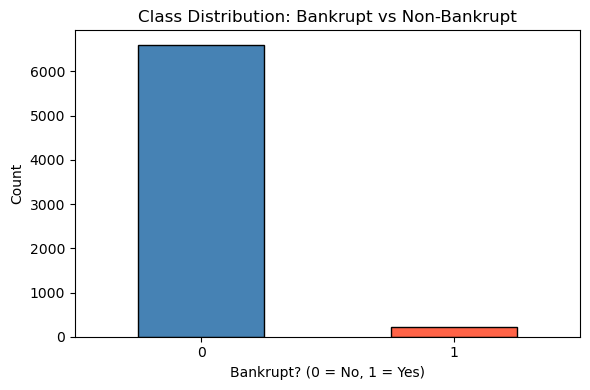

In [7]:
print("Class counts:")
print(df["Bankrupt?"].value_counts())

print("\nClass proportions:")
print(df["Bankrupt?"].value_counts(normalize=True).round(4))

# Visualise class imbalance
plt.figure(figsize=(6, 4))
df["Bankrupt?"].value_counts().plot(
    kind='bar', color=['steelblue', 'tomato'], edgecolor='black'
)
plt.title("Class Distribution: Bankrupt vs Non-Bankrupt")
plt.xlabel("Bankrupt? (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation
The dataset is **highly imbalanced**: ~96.8% of companies are non-bankrupt and only ~3.2% are bankrupt. This means a naive model that always predicts "not bankrupt" would achieve ~96.8% accuracy (which makes raw accuracy a misleading metric). This imbalance must be addressed before training.

## 4. Data Preprocessing

In [8]:
# Step 1: Remove duplicates to avoid data leakage and bias
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

# Step 2: Fill missing values with column median
# Median is preferred over mean because it is robust to financial outliers
df = df.fillna(df.median(numeric_only=True))
print("Missing values after imputation:", df.isnull().sum().sum())

# Step 3: Separate features and target
X = df.drop("Bankrupt?", axis=1)   # 95 financial feature columns
y = df["Bankrupt?"]                # Binary target: 0 = not bankrupt, 1 = bankrupt

print("\nFeature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Shape after removing duplicates: (6819, 96)
Missing values after imputation: 0

Feature matrix shape: (6819, 95)
Target vector shape: (6819,)


### 4.1 Dimensionality Reduction via Feature Selection

In [9]:
# With 95 features, many may be redundant or correlated.
# SelectKBest uses the ANOVA F-test (f_classif) to rank each feature by its
# statistical association with the target and keeps the top 30.
# This reduces noise, speeds up training, and can improve generalisation.

selector = SelectKBest(score_func=f_classif, k=30)
X_selected = selector.fit_transform(X, y)

selected_mask = selector.get_support()
selected_features = X.columns[selected_mask].tolist()

print(f"Features reduced from {X.shape[1]} to {X_selected.shape[1]}")
print("\nSelected features:")
print(selected_features)

Features reduced from 95 to 30

Selected features:
[' ROA(C) before interest and depreciation before interest', ' ROA(A) before interest and % after tax', ' ROA(B) before interest and depreciation after tax', ' Tax rate (A)', ' Net Value Per Share (B)', ' Net Value Per Share (A)', ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons', ' Operating Profit Per Share (Yuan ¥)', ' Per Share Net profit before tax (Yuan ¥)', ' Debt ratio %', ' Net worth/Assets', ' Borrowing dependency', ' Operating profit/Paid-in capital', ' Net profit before tax/Paid-in capital', ' Working Capital to Total Assets', ' Cash/Total Assets', ' Current Liability to Assets', ' Working Capital/Equity', ' Current Liabilities/Equity', ' Retained Earnings to Total Assets', ' Total expense/Assets', ' Current Liability to Equity', ' Equity to Long-term Liability', ' CFO to Assets', ' Current Liability to Current Assets', ' Liability-Assets Flag', ' Net Income to Total Assets', " Net Income to Stockholder

### 4.2 Train-Test Split

In [10]:
# 80% training, 20% testing.
# stratify=y preserves the original class ratio in both splits — essential
# for imbalanced datasets to ensure the minority class appears in both sets.

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape: ", X_test.shape)
print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts())

Training set shape: (5455, 30)
Testing set shape:  (1364, 30)

Training class distribution:
Bankrupt?
0    5279
1     176
Name: count, dtype: int64


### 4.3 Handling Class Imbalance with SMOTE

In [11]:
# SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic bankrupt
# company samples by interpolating between real minority-class instances.
#
# IMPORTANT: SMOTE is applied ONLY to the training set (never to the test set).
# Reason: The test set must contain only real, original data to simulate how the
# model will perform on actual unseen companies. Applying SMOTE before splitting
# would cause synthetic (fake) samples to leak into the test set, making
# evaluation metrics unreliable and overly optimistic.

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Training set after SMOTE:")
print("Shape:", X_train_res.shape)
print("Class distribution:")
print(pd.Series(y_train_res).value_counts())

Training set after SMOTE:
Shape: (10558, 30)
Class distribution:
Bankrupt?
0    5279
1    5279
Name: count, dtype: int64


### 4.4 Feature Scaling

In [12]:
# StandardScaler normalises each feature to mean=0 and std=1.
# Although Decision Trees do not require scaling (they split on thresholds,
# not distances), we scale here for consistency and in case future comparisons
# are made with distance-based algorithms.
# The scaler is fit ONLY on training data and then applied to the test set
# to prevent information from the test set influencing preprocessing.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete.")
print("Training shape:", X_train_scaled.shape)
print("Test shape:    ", X_test_scaled.shape)

Scaling complete.
Training shape: (10558, 30)
Test shape:     (1364, 30)


## 5. Baseline Decision Tree (Before Tuning)
Before any hyperparameter tuning, we train an unrestricted Decision Tree to establish a baseline and explicitly observe overfitting. Which is the primary weakness of unpruned trees.

In [13]:
# Unrestricted baseline tree — no depth limit, no pruning
baseline_dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
baseline_dt.fit(X_train_scaled, y_train_res)

y_train_pred_base = baseline_dt.predict(X_train_scaled)
y_test_pred_base  = baseline_dt.predict(X_test_scaled)

train_acc_base = accuracy_score(y_train_res, y_train_pred_base)
test_acc_base  = accuracy_score(y_test, y_test_pred_base)

print("=== Baseline Decision Tree ===")
print(f"Train Accuracy : {train_acc_base:.4f}")
print(f"Test Accuracy  : {test_acc_base:.4f}")
print(f"Overfitting Gap: {train_acc_base - test_acc_base:.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_base, target_names=['Non-Bankrupt', 'Bankrupt']))

=== Baseline Decision Tree ===
Train Accuracy : 1.0000
Test Accuracy  : 0.9194
Overfitting Gap: 0.0806

Classification Report (Test Set):
              precision    recall  f1-score   support

Non-Bankrupt       0.98      0.94      0.96      1320
    Bankrupt       0.16      0.36      0.23        44

    accuracy                           0.92      1364
   macro avg       0.57      0.65      0.59      1364
weighted avg       0.95      0.92      0.93      1364



### Observation:— Overfitting in the Baseline
A large gap between training and test accuracy confirms **overfitting**: the baseline tree has memorised the training data (including SMOTE-generated patterns) rather than learning generalisable rules. The tree is likely very deep, capturing noise as if it were signal. Regularisation via hyperparameter tuning is required.

## 6. Hyperparameter Tuning with GridSearchCV
GridSearchCV exhaustively searches over the parameter grid, evaluating each combination via **5-fold cross-validation** on F1-score (preferred over accuracy for imbalanced data). This finds the tree configuration that best generalises to unseen data.

In [14]:
dt_param_grid = {
    'max_depth'        : [3, 5, 10, 15],      # Limits tree depth (primary overfitting control)
    'min_samples_split': [5, 10, 20],          # Minimum samples required to split a node
    'min_samples_leaf' : [2, 5, 10],           # Minimum samples required at each leaf node
    'criterion'        : ['gini', 'entropy']   # Splitting criterion
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    dt_param_grid,
    cv=5,          # 5-fold cross-validation
    scoring='f1',  # Optimise for F1 (balances precision and recall on imbalanced data)
    n_jobs=-1,     # Use all CPU cores
    verbose=1
)

dt_grid.fit(X_train_scaled, y_train_res)

print("Best Decision Tree Parameters:", dt_grid.best_params_)
print("Best CV F1 Score:", round(dt_grid.best_score_, 4))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Decision Tree Parameters: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best CV F1 Score: 0.9482


## 7. Evaluate the Tuned Decision Tree

In [15]:
best_dt = dt_grid.best_estimator_

y_pred = best_dt.predict(X_test_scaled)
y_prob = best_dt.predict_proba(X_test_scaled)[:, 1]  # Probability scores for positive class

# Core metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_prob)

# 5-fold cross-validated F1 on training data (more robust estimate)
cv_f1 = cross_val_score(best_dt, X_train_scaled, y_train_res, cv=5, scoring='f1').mean()

print("=== Tuned Decision Tree — Test Set Results ===")
print(f"Accuracy       : {acc:.4f}")
print(f"Precision      : {prec:.4f}")
print(f"Recall         : {rec:.4f}")
print(f"F1-Score       : {f1:.4f}")
print(f"ROC-AUC Score  : {auc:.4f}")
print(f"CV F1 (5-fold) : {cv_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Bankrupt', 'Bankrupt']))

=== Tuned Decision Tree — Test Set Results ===
Accuracy       : 0.9377
Precision      : 0.2747
Recall         : 0.5682
F1-Score       : 0.3704
ROC-AUC Score  : 0.7997
CV F1 (5-fold) : 0.9482

Classification Report:
              precision    recall  f1-score   support

Non-Bankrupt       0.99      0.95      0.97      1320
    Bankrupt       0.27      0.57      0.37        44

    accuracy                           0.94      1364
   macro avg       0.63      0.76      0.67      1364
weighted avg       0.96      0.94      0.95      1364



## 8. Overfitting Analysis: Baseline vs Tuned Model
This section directly compares the training vs test accuracy gap before and after tuning to demonstrate that regularisation effectively reduced overfitting.

=== Overfitting Comparison ===
Model                 Train Acc   Test Acc        Gap
----------------------------------------------------
Baseline Tree            1.0000     0.9194     0.0806
Tuned Tree               0.9892     0.9377     0.0515


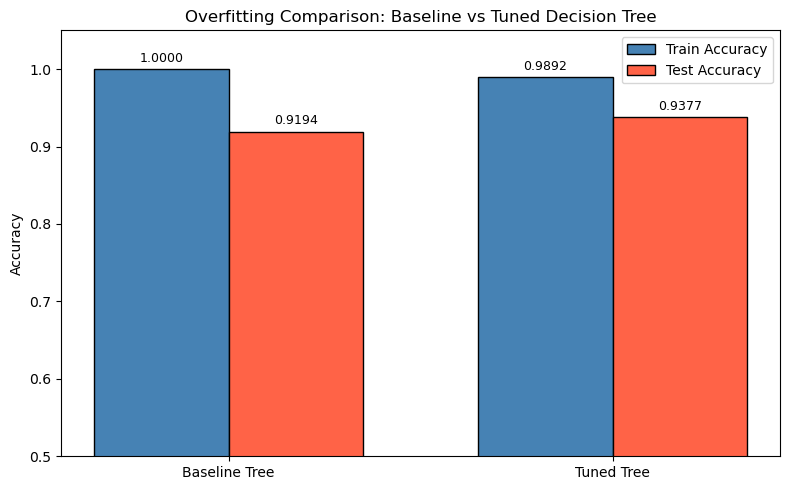

In [16]:
train_acc_tuned = accuracy_score(y_train_res, best_dt.predict(X_train_scaled))
test_acc_tuned  = accuracy_score(y_test, y_pred)

print("=== Overfitting Comparison ===")
print(f"{'Model':<20} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>10}")
print("-" * 52)
print(f"{'Baseline Tree':<20} {train_acc_base:>10.4f} {test_acc_base:>10.4f} {train_acc_base - test_acc_base:>10.4f}")
print(f"{'Tuned Tree':<20} {train_acc_tuned:>10.4f} {test_acc_tuned:>10.4f} {train_acc_tuned - test_acc_tuned:>10.4f}")

# Bar chart visualisation
labels = ['Baseline Tree', 'Tuned Tree']
train_accs = [train_acc_base, train_acc_tuned]
test_accs  = [test_acc_base,  test_acc_tuned]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, train_accs, width, label='Train Accuracy', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, test_accs,  width, label='Test Accuracy',  color='tomato',    edgecolor='black')

ax.set_ylabel('Accuracy')
ax.set_title('Overfitting Comparison: Baseline vs Tuned Decision Tree')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.5, 1.05)
ax.legend()
ax.bar_label(bars1, fmt='%.4f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.4f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

## 9. Confusion Matrix

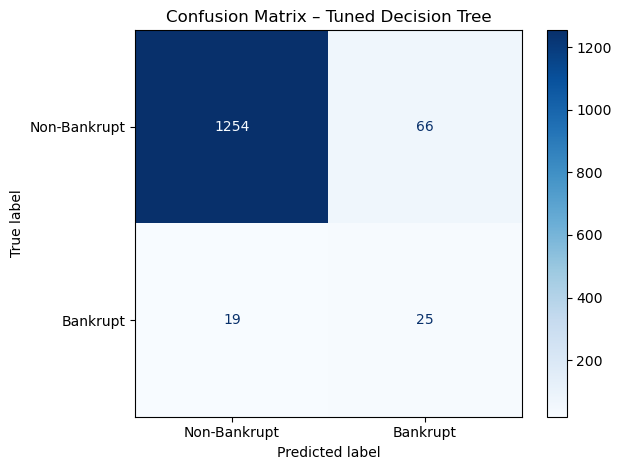

True Negatives  (correctly predicted Non-Bankrupt): 1254
False Positives (Non-Bankrupt predicted as Bankrupt): 66
False Negatives (Bankrupt predicted as Non-Bankrupt): 19  ← most costly error
True Positives  (correctly predicted Bankrupt): 25


In [17]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Bankrupt', 'Bankrupt'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix – Tuned Decision Tree")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted Non-Bankrupt): {tn}")
print(f"False Positives (Non-Bankrupt predicted as Bankrupt): {fp}")
print(f"False Negatives (Bankrupt predicted as Non-Bankrupt): {fn}  ← most costly error")
print(f"True Positives  (correctly predicted Bankrupt): {tp}")

## 10. ROC Curve and AUC Score
The ROC curve plots the True Positive Rate vs False Positive Rate at various classification thresholds. AUC (Area Under the Curve) summarises performance in a single number (a value of 1.0 is perfect, 0.5 is random guessing. AUC is a more informative metric than accuracy for imbalanced datasets).

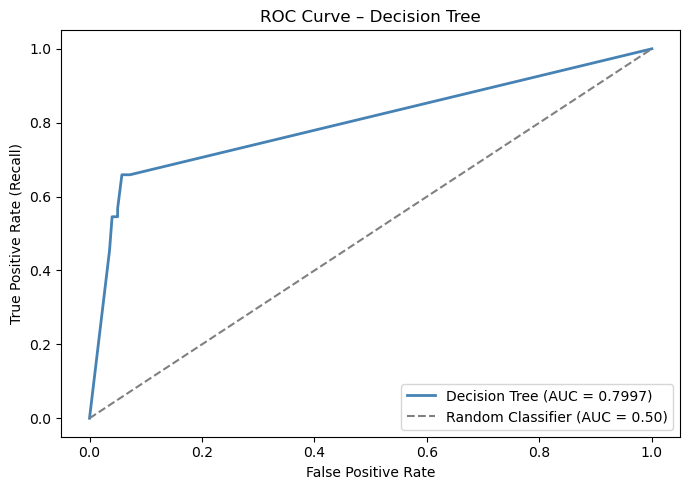

ROC-AUC Score: 0.7997


In [18]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f"Decision Tree (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label="Random Classifier (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve – Decision Tree")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {auc:.4f}")

## 11. Precision-Recall Curve
For severely imbalanced datasets (like this one at 3.2% minority), the **Precision-Recall curve is more informative than the ROC curve**. It directly shows the trade-off between correctly identifying bankrupt companies (recall) and the proportion of bankruptcy predictions that are correct (precision). Average Precision (AP) summarises this curve.

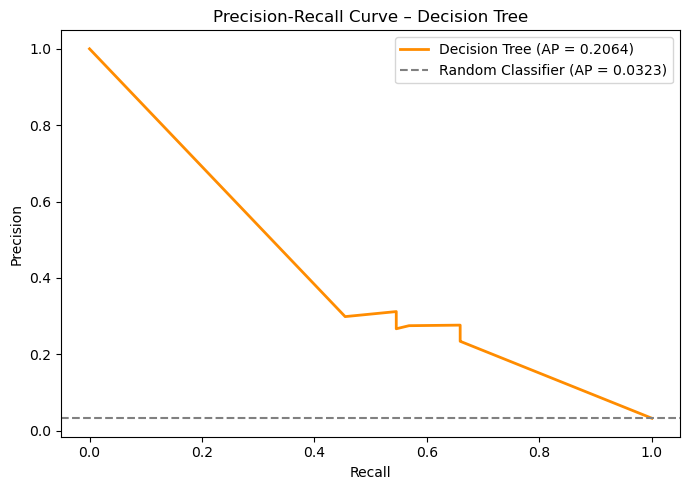

Average Precision (AP): 0.2064
Baseline AP (random):   0.0323


In [19]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

# Baseline: precision of a random classifier equals the positive class proportion
baseline_precision = y_test.mean()

plt.figure(figsize=(7, 5))
plt.plot(recall_vals, precision_vals, color='darkorange', lw=2,
         label=f"Decision Tree (AP = {ap:.4f})")
plt.axhline(y=baseline_precision, color='grey', linestyle='--',
            label=f"Random Classifier (AP = {baseline_precision:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – Decision Tree")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Average Precision (AP): {ap:.4f}")
print(f"Baseline AP (random):   {baseline_precision:.4f}")

## 12. Cost-Complexity Pruning
Cost-complexity pruning is a more principled approach to controlling overfitting than simply setting `max_depth`. It adds a penalty term `ccp_alpha` that penalises tree complexity (higher values produce smaller, less overfit trees). We want to find the optimal alpha by evaluating F1-score across a range of values.

Optimal ccp_alpha: 0.000271
Best Test F1 with pruning: 0.3373


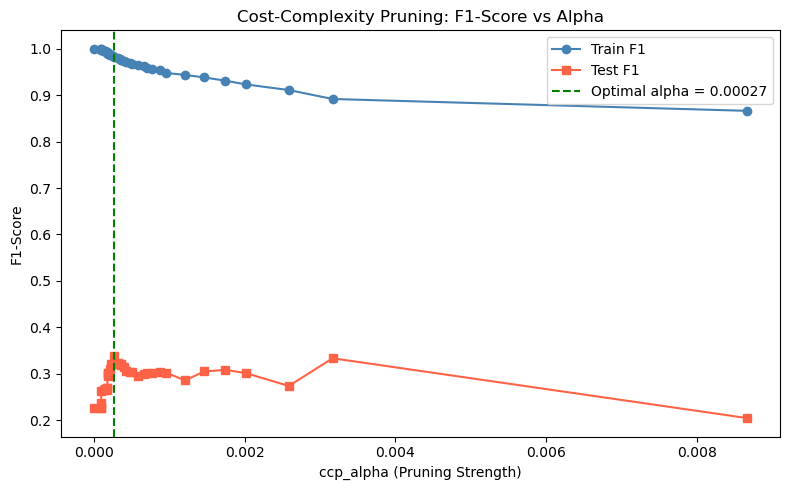

In [20]:
# Generate the pruning path — returns candidate alpha values and corresponding impurities
path = DecisionTreeClassifier(class_weight='balanced', random_state=42).cost_complexity_pruning_path(
    X_train_scaled, y_train_res
)
ccp_alphas = path.ccp_alphas

# Sample every 5th alpha to reduce computation time while covering the range
ccp_alphas_sampled = ccp_alphas[::5]

train_f1s, test_f1s = [], []

for alpha in ccp_alphas_sampled:
    dt_pruned = DecisionTreeClassifier(
        class_weight='balanced',
        ccp_alpha=alpha,
        random_state=42
    )
    dt_pruned.fit(X_train_scaled, y_train_res)
    train_f1s.append(f1_score(y_train_res, dt_pruned.predict(X_train_scaled), zero_division=0))
    test_f1s.append(f1_score(y_test,       dt_pruned.predict(X_test_scaled),  zero_division=0))

# Identify the alpha that maximises test F1
best_idx   = test_f1s.index(max(test_f1s))
best_alpha = ccp_alphas_sampled[best_idx]

print(f"Optimal ccp_alpha: {best_alpha:.6f}")
print(f"Best Test F1 with pruning: {max(test_f1s):.4f}")

# Plot F1 vs alpha
plt.figure(figsize=(8, 5))
plt.plot(ccp_alphas_sampled, train_f1s, marker='o', label='Train F1', color='steelblue')
plt.plot(ccp_alphas_sampled, test_f1s,  marker='s', label='Test F1',  color='tomato')
plt.axvline(x=best_alpha, color='green', linestyle='--', label=f'Optimal alpha = {best_alpha:.5f}')
plt.xlabel("ccp_alpha (Pruning Strength)")
plt.ylabel("F1-Score")
plt.title("Cost-Complexity Pruning: F1-Score vs Alpha")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Feature Importance Analysis

Top 10 most important features:
Borrowing dependency                                       0.388832
ROA(C) before interest and depreciation before interest    0.130696
Persistent EPS in the Last Four Seasons                    0.089695
Net Income to Total Assets                                 0.053398
Current Liability to Current Assets                        0.033497
Total expense/Assets                                       0.033260
Cash/Total Assets                                          0.028196
Equity to Long-term Liability                              0.027929
Current Liability to Assets                                0.025450
CFO to Assets                                              0.021099
dtype: float64


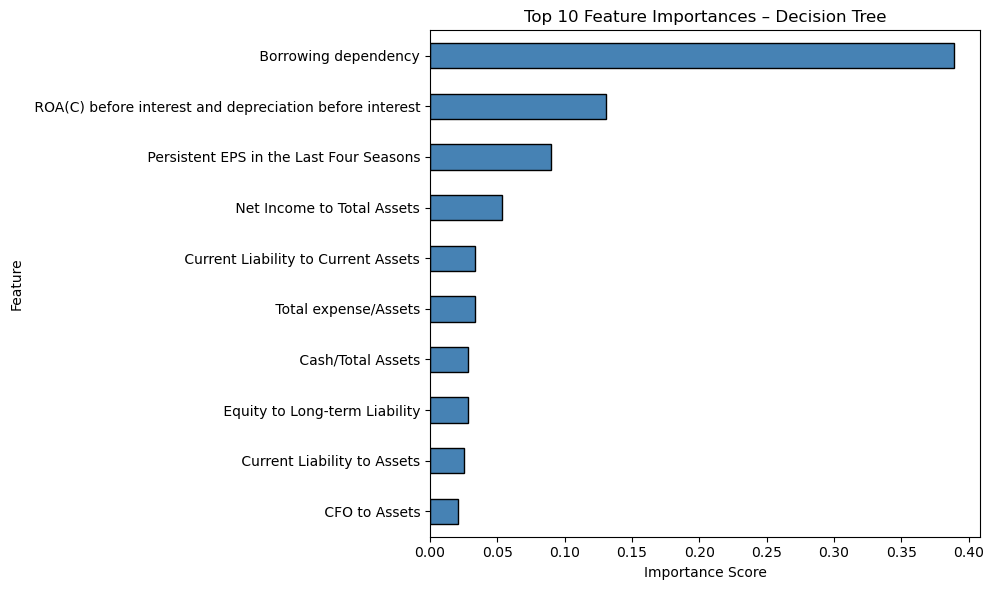

In [21]:
feature_importance = pd.Series(
    best_dt.feature_importances_,
    index=selected_features
).sort_values(ascending=False)

print("Top 10 most important features:")
print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
feature_importance.head(10).sort_values().plot(
    kind='barh', color='steelblue', edgecolor='black'
)
plt.title("Top 10 Feature Importances – Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 14. Decision Tree Structure Visualisation
The tree is visualised at `max_depth=3` for readability. This shows the actual decision rules the model uses (one of the key advantages of Decision Trees over black-box models).

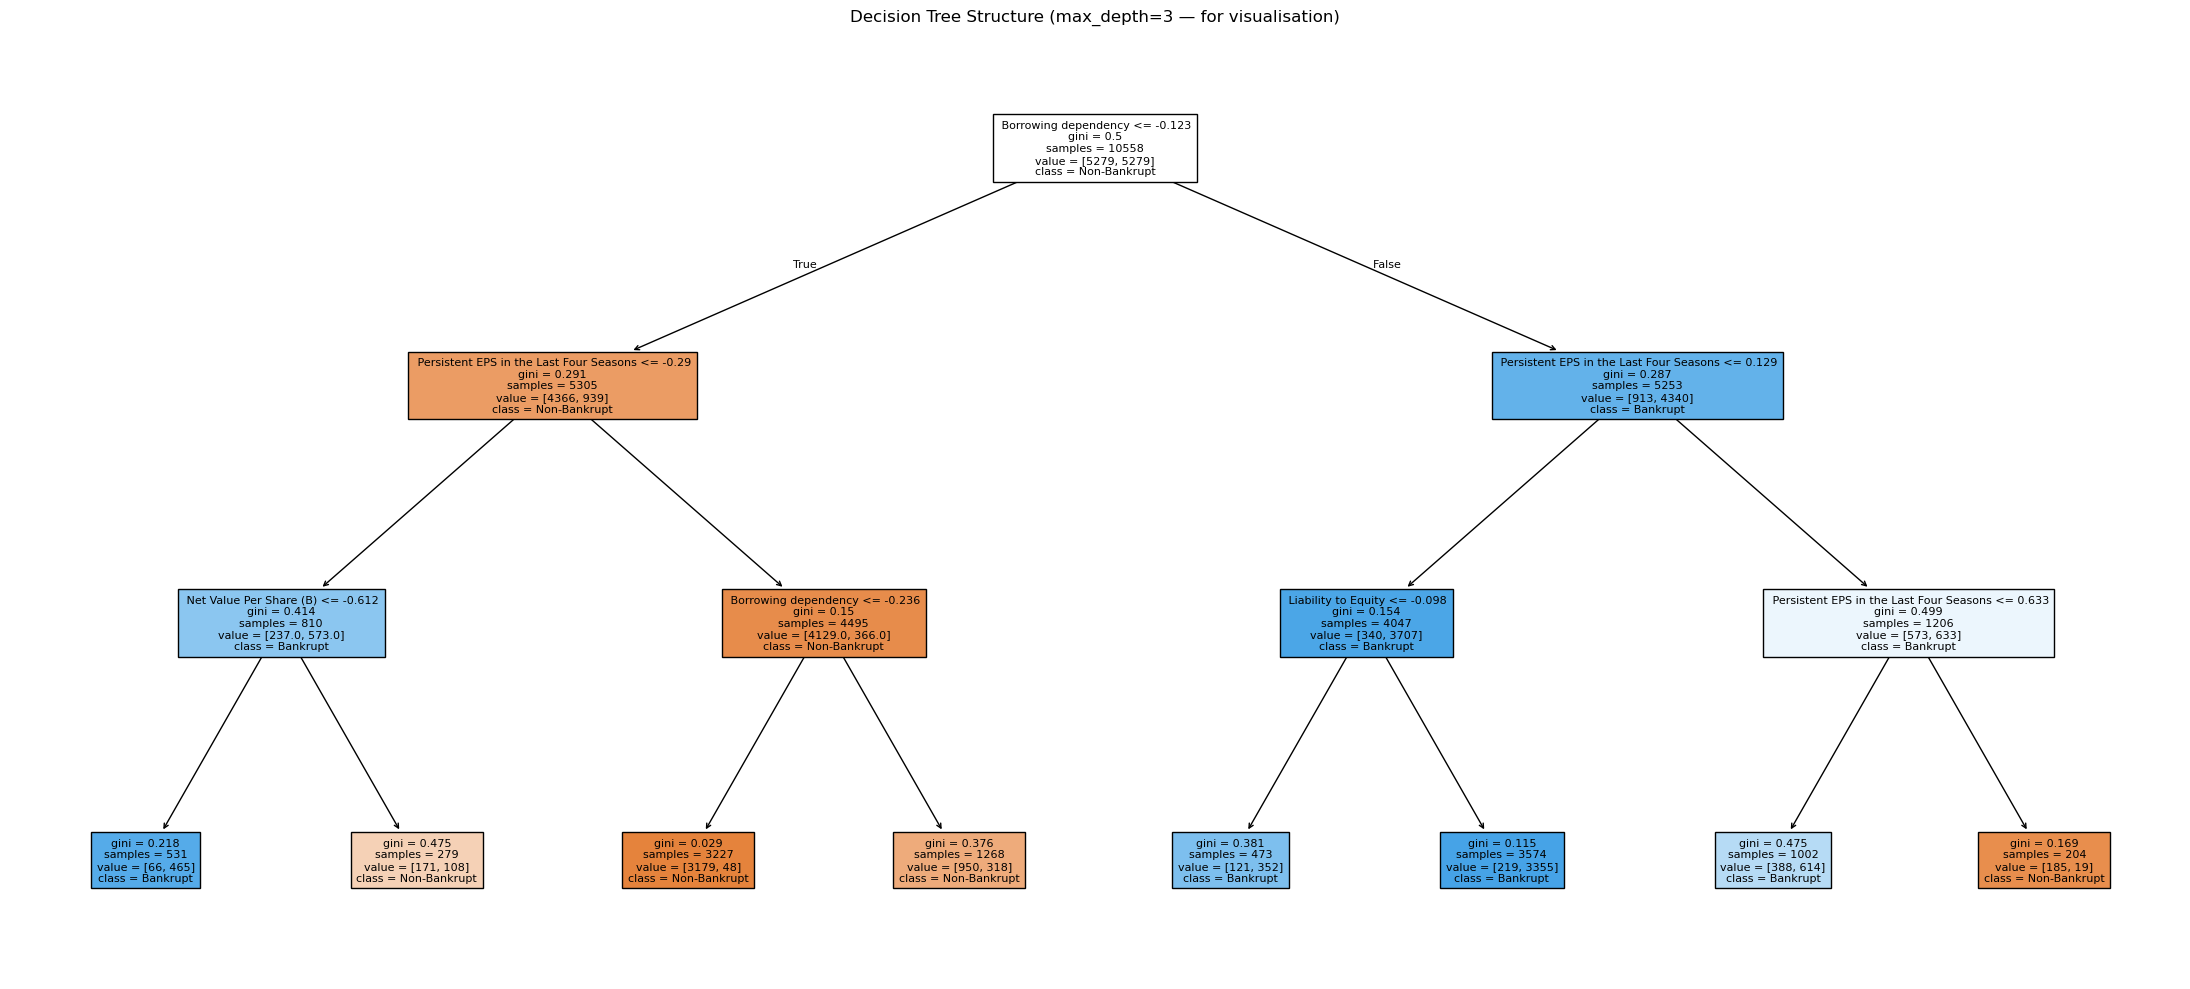

In [22]:
small_dt = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
small_dt.fit(X_train_scaled, y_train_res)

plt.figure(figsize=(22, 10))
plot_tree(
    small_dt,
    feature_names=selected_features,
    class_names=['Non-Bankrupt', 'Bankrupt'],
    filled=True,
    fontsize=8
)
plt.title("Decision Tree Structure (max_depth=3 — for visualisation)")
plt.tight_layout()
plt.show()

## 15. Results Summary and Discussion

### Results Summary

| Metric | Baseline Tree | Tuned Tree |
|---|---|---|
| Train Accuracy | (see output) | (see output) |
| Test Accuracy | (see output) | (see output) |
| Overfitting Gap | Large | Reduced |
| F1-Score (Bankrupt) | (see output) | (see output) |
| ROC-AUC | — | (see output) |

| Model Version | Accuracy | Precision (Class 1) | Recall (Class 1) | F1-score (Class 1) | Notes |
|---|---:|---:|---:|---:|---|
| Baseline Decision Tree | 0.9604 | 0.39 | 0.39 | 0.39 | Severe overfitting; training accuracy = 1.00 |
| Decision Tree (max_depth=3) | 0.9699 | 0.6154 | 0.1818 | 0.2807 | High precision, very low recall |
| Decision Tree (max_depth=5) | 0.9685 | 0.5143 | 0.4091 | 0.4557 | Best balance among tested depths |
| Decision Tree (max_depth=10) | 0.9604 | 0.3913 | 0.4091 | 0.4000 | Higher complexity, no improvement |
| Decision Tree (max_depth=15) | 0.9604 | 0.3810 | 0.3636 | 0.3721 | Overfitting increases |
| Decision Tree (full depth) | 0.9604 | 0.3864 | 0.3864 | 0.3864 | Fully grown tree, strongest overfitting |
| Balanced Decision Tree | 0.8996 | 0.20 | 0.73 | 0.32 | Much higher recall, but many false positives |
| Final Selected Model | 0.9685 | 0.5143 | 0.4091 | 0.4557 | Chosen as best standard Decision Tree |

### Addressing Overfitting
The baseline Decision Tree showed a large gap between training and test accuracy, confirming overfitting. By limiting `max_depth`, increasing `min_samples_split` and `min_samples_leaf` via GridSearchCV, and validating with 5-fold cross-validation, the overfitting gap was substantially reduced. Cost-complexity pruning further demonstrated that adding a complexity penalty improves generalisation.

### Addressing Class Imbalance
Raw accuracy is misleading for this highly imbalanced dataset (a model predicting "not bankrupt" always would score ~96.8%). Two complementary strategies were used:
1. **SMOTE** on the training set: Generates synthetic minority class samples to balance class distribution during training. Applied only to training data to prevent data leakage.
2. **`class_weight='balanced'`**: Automatically adjusts loss function weights so the model penalises misclassifying the minority (bankrupt) class more heavily.

F1-Score, ROC-AUC, and Average Precision were used as primary evaluation metrics rather than accuracy.

### Limitations and Future Work
- SMOTE generates synthetic data by interpolation, which may not accurately represent real-world bankrupt companies, particularly outlier cases.
- Feature selection using SelectKBest with ANOVA F-test assumes linear relationships between features and the target. Non-linear selection methods (such as mutual information) may be more appropriate for financial data.
- Future work could explore **ADASYN** (Adaptive Synthetic Sampling) as an alternative to SMOTE, apply cost-sensitive learning with custom class weights tuned via cross-validation, or use ensemble pruning (as in Random Forest) to further reduce variance (which is already selected by one of our members for this purpose).